Revenue Analysis:
1. Monthly revenue trend analysis.
2. Average order value examination.
3. Identification of peak revenue hours.
4. Determining the most profitable day of the week.
5. Evaluation of the average revenue per customer.

In [2]:
# read bigquery data into pandas dataframe
import pandas as pd


df = pd.read_gbq(
    """
    SELECT  *
    FROM `jr-data-training.cafe.cafe-sales`
    --- LIMIT 10
  """,
    project_id="jr-data-training",
    location="australia-southeast1",
)

C:\Users\Jack\AppData\Local\Temp\ipykernel_31316\265903226.py:5: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df = pd.read_gbq(
C:\Users\Jack\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\google\auth\_default.py:76: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


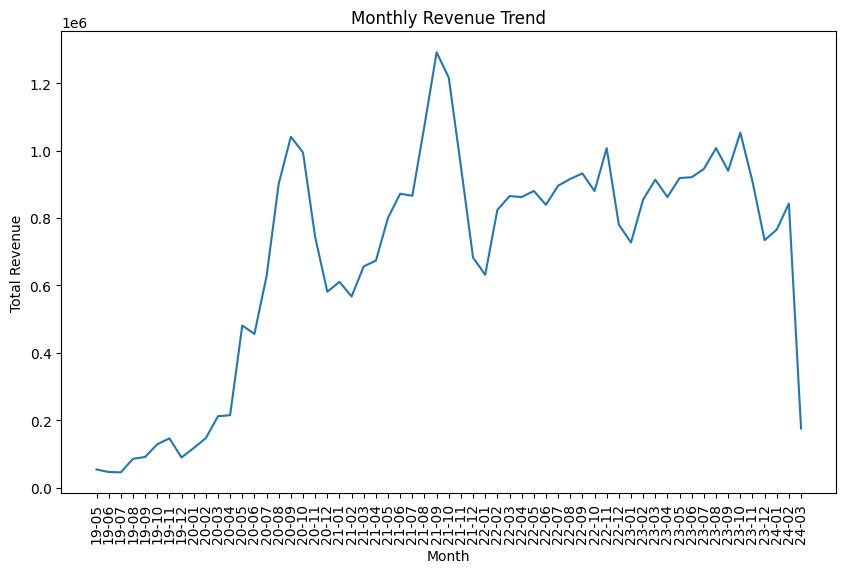

In [10]:
# 1. Monthly revenue trend analysis.
import matplotlib.pyplot as plt

df['date_paid'] = pd.to_datetime(df['date_paid'])
df['month'] = df['date_paid'].dt.to_period('M')
monthly_revenue = df.groupby('month')['total'].sum().reset_index()
monthly_revenue['month_str'] = monthly_revenue['month'].dt.strftime('%y-%m')

# # plot
plt.figure(figsize=(10, 6))  # 可调节图表大小
plt.plot(monthly_revenue['month_str'], monthly_revenue['total'])
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.title('Monthly Revenue Trend')
plt.xticks(rotation=90)  # 将日期标签旋转90度竖直显示
plt.show()

# plt.show()


In [11]:
#2. Average order value examination.
avg_order_value = df['total'].mean()
print(f"Average Order Value: {avg_order_value}")

Average Order Value: 1122.558840843412


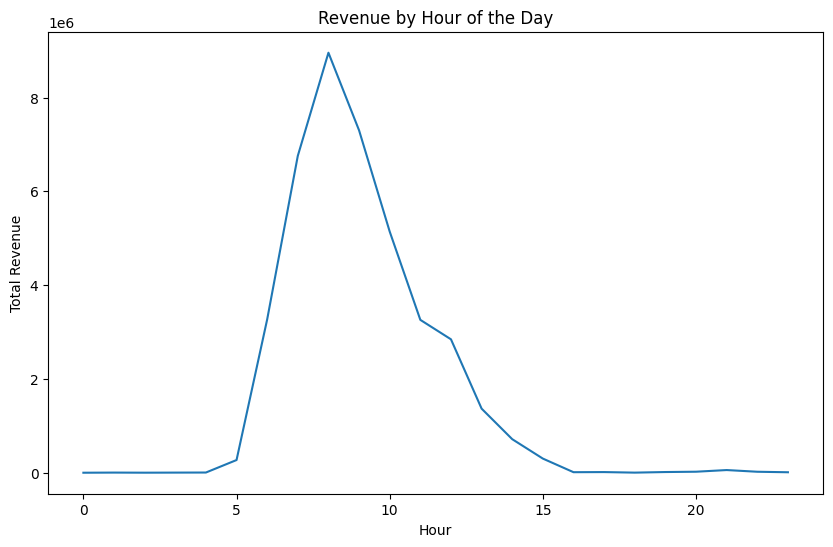

Peak Revenue Hour: 8.0


In [13]:
#3. Identification of peak revenue hours.
df['hour'] = df['date_paid'].dt.hour
hourly_revenue = df.groupby('hour')['total'].sum().reset_index()

# 可视化每小时收入
plt.figure(figsize=(10, 6)) 
plt.plot(hourly_revenue['hour'], hourly_revenue['total'])
plt.xlabel('Hour')
plt.ylabel('Total Revenue')
plt.title('Revenue by Hour of the Day')
plt.show()

# 识别收入峰值时间段
peak_hour = hourly_revenue.loc[hourly_revenue['total'].idxmax(), 'hour']
print(f"Peak Revenue Hour: {peak_hour}")

Most Profitable Day of the Week: Saturday


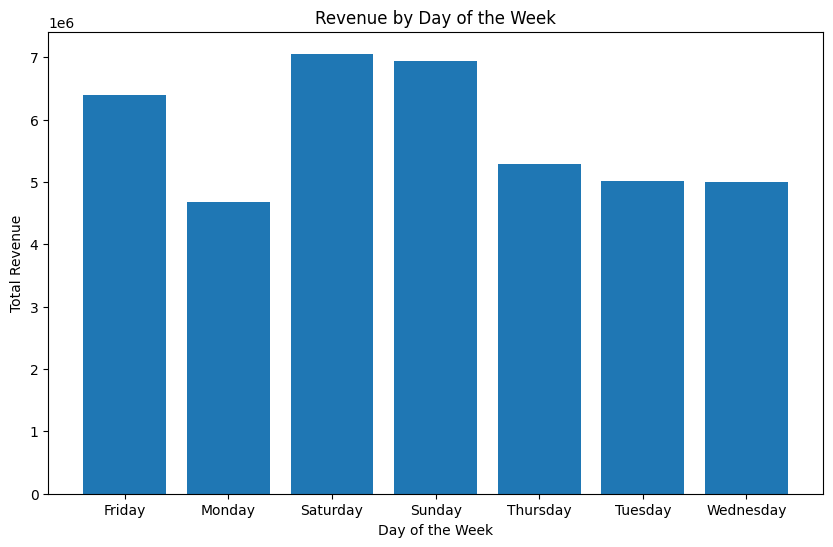

In [19]:
#4. Determining the most profitable day of the week.
df['weekday'] = df['date_paid'].dt.day_name()
daily_revenue = df.groupby('weekday')['total'].sum().reset_index()

# 找出收入最多的一天
most_profitable_day = daily_revenue.loc[daily_revenue['total'].idxmax(), 'weekday']
print(f"Most Profitable Day of the Week: {most_profitable_day}")

# 可视化每周收入
plt.figure(figsize=(10,6))
plt.bar(daily_revenue['weekday'], daily_revenue['total'])
plt.xlabel('Day of the Week')
plt.ylabel('Total Revenue')
plt.title('Revenue by Day of the Week')
plt.show()

In [20]:
#5. Evaluation of the average revenue per customer.
customer_revenue = df.groupby('customer_id')['total'].sum()
avg_revenue_per_customer = customer_revenue.mean()
print(f"Average Revenue Per Customer: {avg_revenue_per_customer}")

Average Revenue Per Customer: 23904.42678062678
